<a href="https://colab.research.google.com/github/udjonah/Paper-1/blob/main/Paper_1_Update.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving outsourcing_wage_inflation_dataset_2010_2025 - Copy.xlsx to outsourcing_wage_inflation_dataset_2010_2025 - Copy.xlsx


In [2]:
import pandas as pd

In [3]:
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name)
display(df.head())

,Year,Firm ID,Sector,Wage Inflation (%),Routine Task Outsourcing Intensity,Outsourcing Location,Contractual Structure,"Labor Productivity (Output/Worker, $k)",Firm Size (Employees),"Capital Intensity (Capital/Labor, $k)",Sector Growth (%),Global Supply Shock Index
0,2010,F001,Manufacturing,2.58,0.20,Domestic,Gig/Freelance,69.5,1874,96.1,2.04,0.12
1,2011,F001,Manufacturing,3.74,0.40,Domestic,Gig/Freelance,71.5,1874,96.7,2.22,0.18
2,2012,F001,Manufacturing,3.08,0.39,Domestic,Gig/Freelance,69.1,1874,93.3,1.34,0.10
3,2013,F001,Manufacturing,3.36,0.22,Domestic,Gig/Freelance,77.8,1874,95.6,2.55,0.08
4,2014,F001,Manufacturing,3.29,0.22,Domestic,Gig/Freelance,75.3,1874,105.7,2.73,0.09


/tmp/ipykernel_1183/126064295.py:35: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df, x='Year', y='Wage Inflation (%)', hue='Sector',
/tmp/ipykernel_1183/126064295.py:43: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df, x='Year', y='Routine Task Outsourcing Intensity',


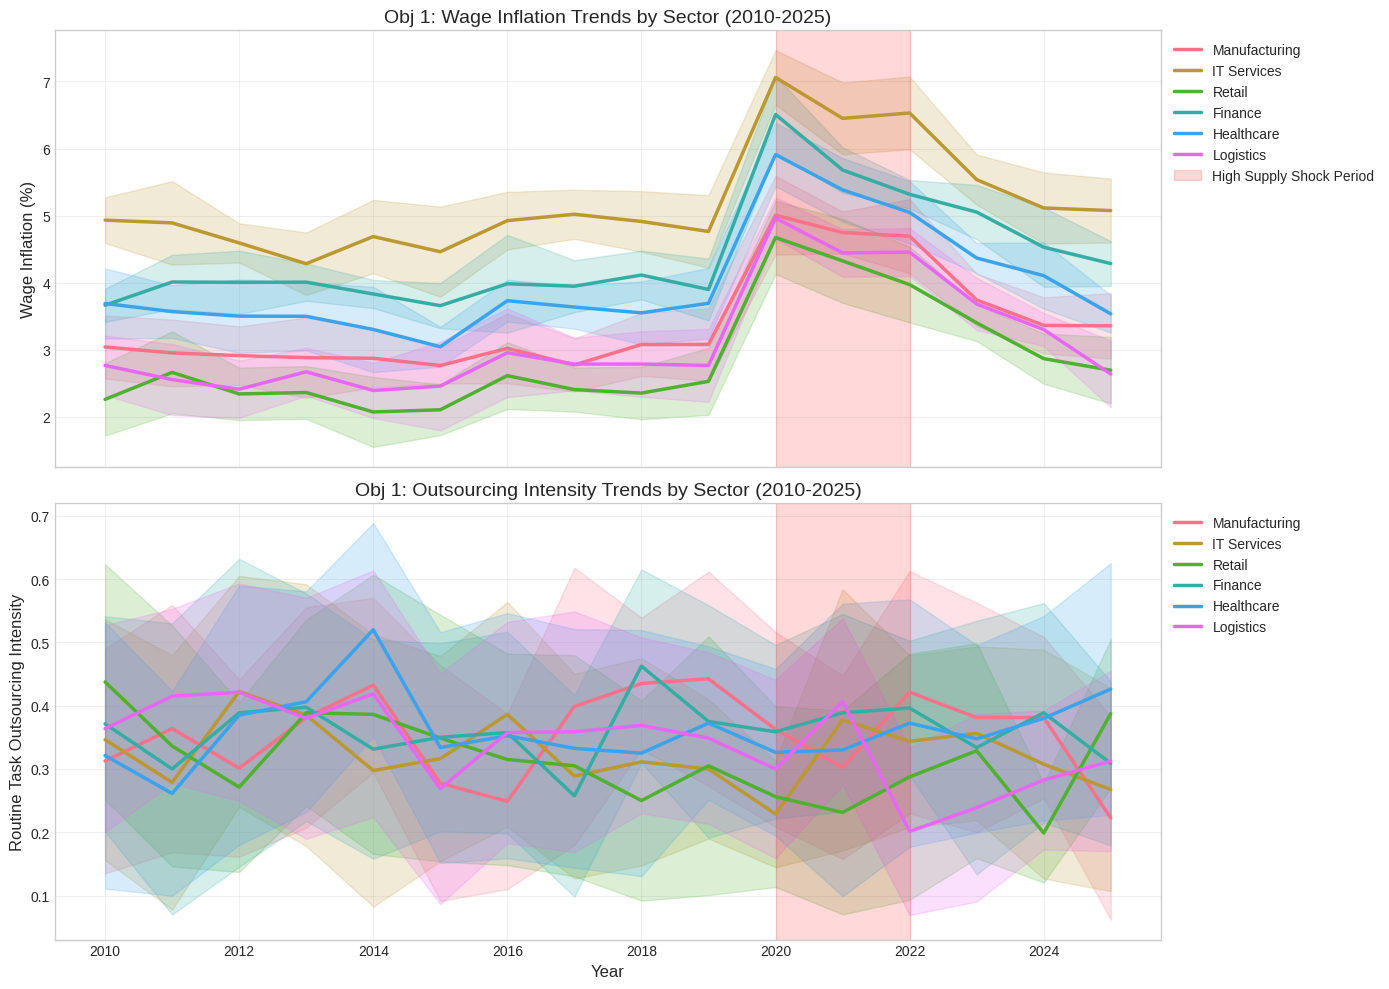

/tmp/ipykernel_1183/126064295.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outsourcing Location', y='Wage Inflation (%)',
/tmp/ipykernel_1183/126064295.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Contractual Structure', y='Wage Inflation (%)',


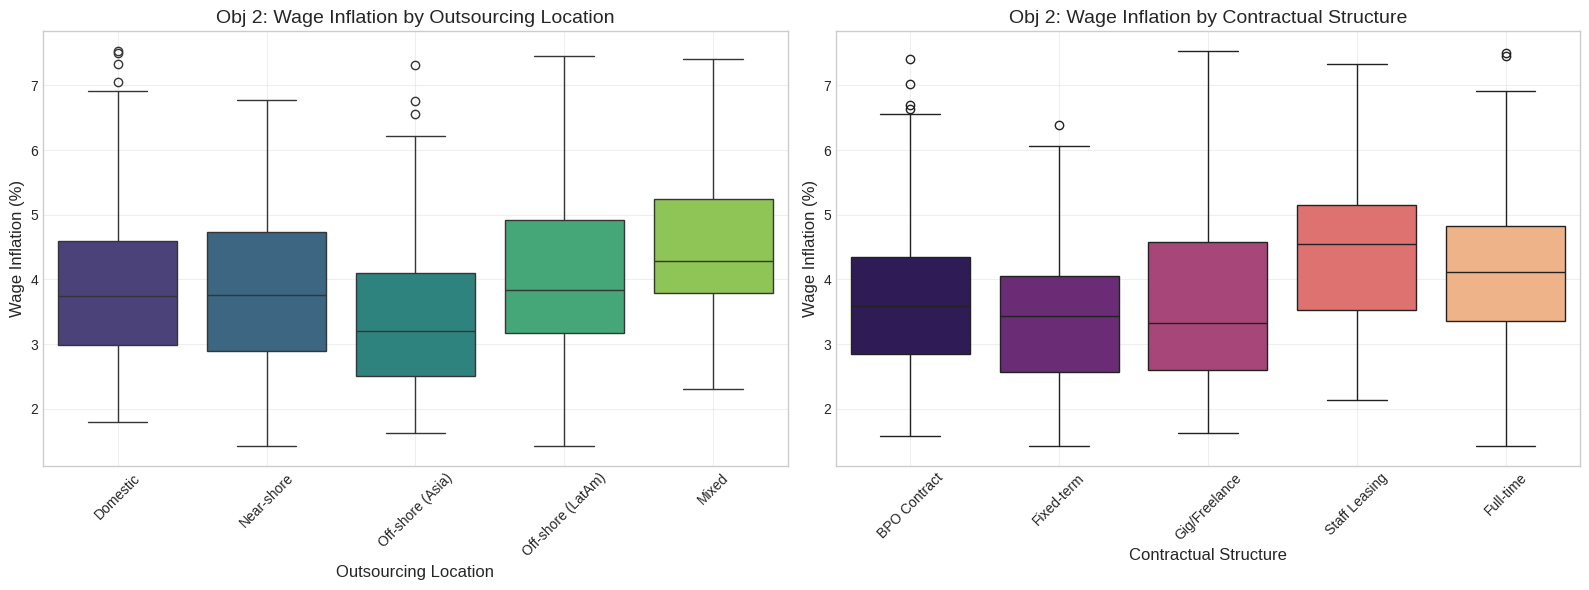

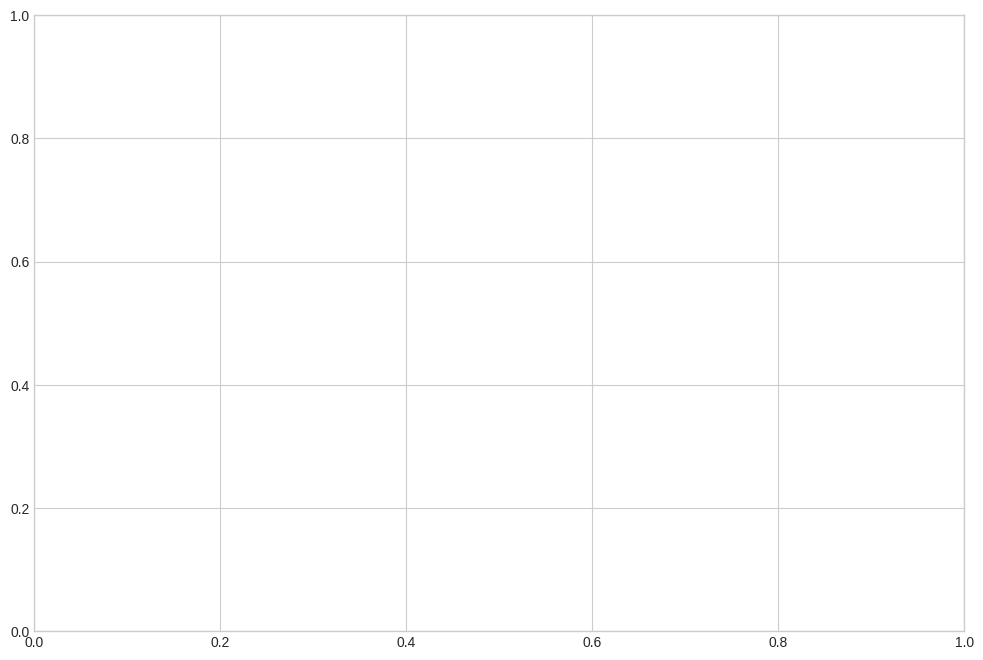

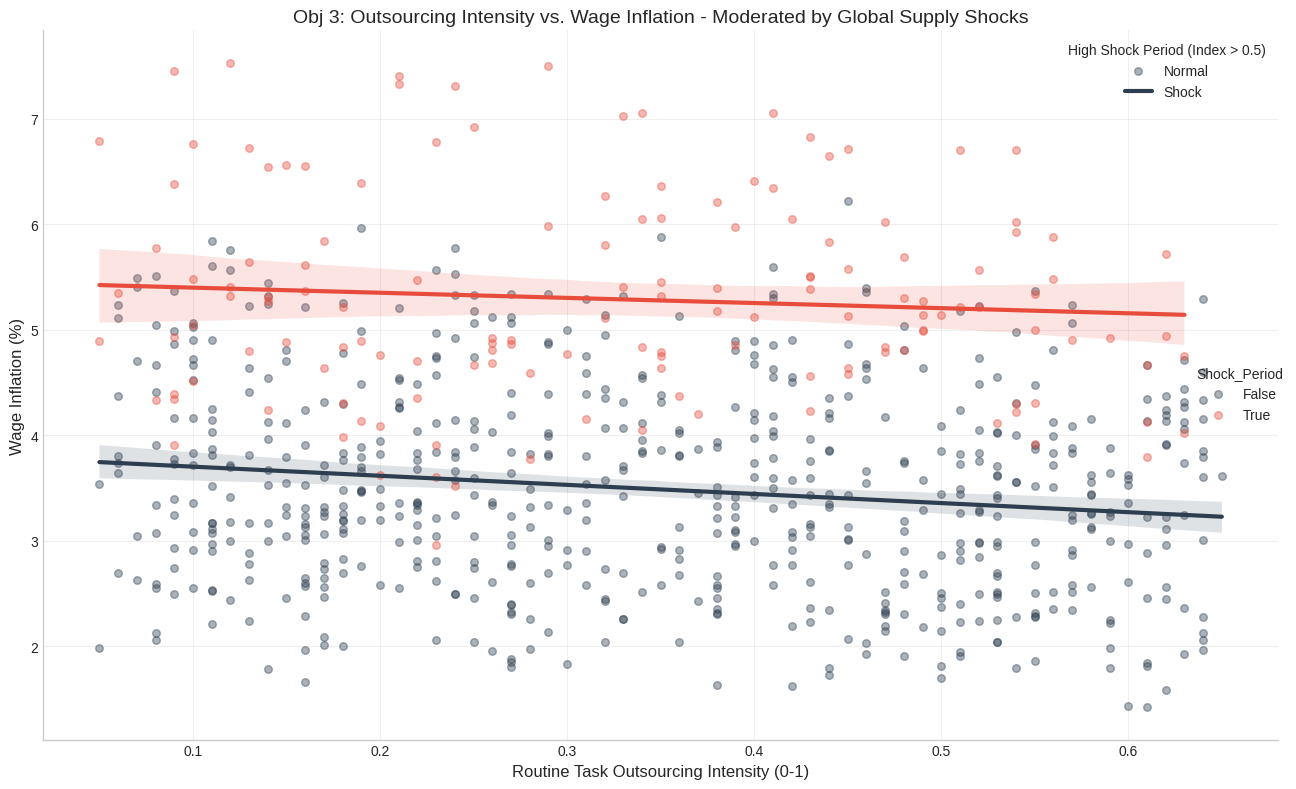

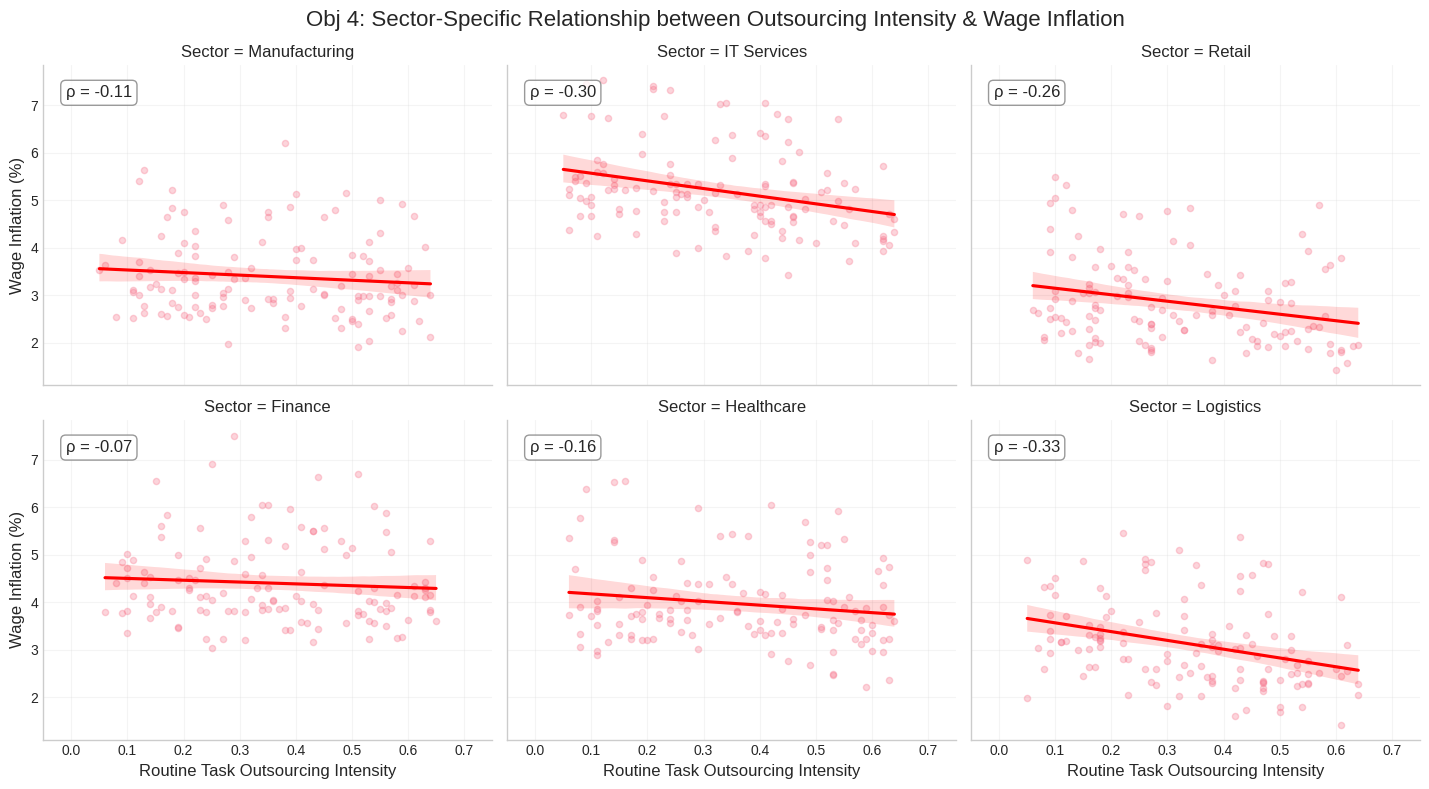

=== DESCRIPTIVE STATISTICS FOR THE FULL SAMPLE ===
       Wage Inflation (%)  Routine Task Outsourcing Intensity  \
count              768.00                              768.00   
mean                 3.83                                0.34   
std                  1.20                                0.17   
min                  1.42                                0.05   
25%                  2.96                                0.19   
50%                  3.74                                0.34   
75%                  4.66                                0.49   
max                  7.53                                0.65   

       Labor Productivity (Output/Worker, $k)  \
count                                  768.00   
mean                                    99.32   
std                                     43.07   
min                                     34.40   
25%                                     62.88   
50%                                     87.35   
75%                 

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set aesthetic style for publication-ready figures
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# ----------------------------
# 1. LOAD AND PREPARE DATA
# ----------------------------
# Load the specific sheet from the Excel file
file_path = 'outsourcing_wage_inflation_dataset_2010_2025 - Copy.xlsx'
df = pd.read_excel(file_path, sheet_name='Panel Data')

# Ensure correct data types
df['Year'] = df['Year'].astype(int)
df['Wage Inflation (%)'] = df['Wage Inflation (%)'].astype(float)
df['Routine Task Outsourcing Intensity'] = df['Routine Task Outsourcing Intensity'].astype(float)
df['Global Supply Shock Index'] = df['Global Supply Shock Index'].astype(float)

# Create a binary flag for "High Shock" periods (e.g., > 0.5 distinctly captures 2020-2022)
df['Shock_Period'] = df['Global Supply Shock Index'] > 0.5

# ----------------------------------------
# 2. OBJECTIVE 1: TEMPORAL TRENDS BY SECTOR
# ----------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot A: Wage Inflation over time
sns.lineplot(data=df, x='Year', y='Wage Inflation (%)', hue='Sector',
             ci='sd', estimator='mean', ax=axes[0], linewidth=2.5)
axes[0].set_title('Obj 1: Wage Inflation Trends by Sector (2010-2025)')
axes[0].axvspan(2020, 2022, alpha=0.15, color='red', label='High Supply Shock Period')
axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1))
axes[0].grid(True, alpha=0.3)

# Plot B: Outsourcing Intensity over time
sns.lineplot(data=df, x='Year', y='Routine Task Outsourcing Intensity',
             hue='Sector', ci='sd', estimator='mean', ax=axes[1], linewidth=2.5)
axes[1].set_title('Obj 1: Outsourcing Intensity Trends by Sector (2010-2025)')
axes[1].axvspan(2020, 2022, alpha=0.15, color='red')
axes[1].legend(loc='upper left', bbox_to_anchor=(1, 1))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Objective_1_Temporal_Trends.png', dpi=300, bbox_inches='tight')
plt.show()

# ------------------------------------------------
# 3. OBJECTIVE 2: CATEGORICAL HETEROGENEITY
# ------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot C: Wage Inflation by Outsourcing Location
sns.boxplot(data=df, x='Outsourcing Location', y='Wage Inflation (%)',
            ax=axes[0], palette='viridis', order=df['Outsourcing Location'].value_counts().index)
axes[0].set_title('Obj 2: Wage Inflation by Outsourcing Location')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# Plot D: Wage Inflation by Contractual Structure
sns.boxplot(data=df, x='Contractual Structure', y='Wage Inflation (%)',
            ax=axes[1], palette='magma', order=df['Contractual Structure'].value_counts().index)
axes[1].set_title('Obj 2: Wage Inflation by Contractual Structure')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Objective_2_Categorical_Heterogeneity.png', dpi=300, bbox_inches='tight')
plt.show()

# --------------------------------------------------
# 4. OBJECTIVE 3: MODERATING EFFECT OF SUPPLY SHOCKS
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot with regression fits conditioned on Shock Period
sns.lmplot(data=df, x='Routine Task Outsourcing Intensity', y='Wage Inflation (%)',
           hue='Shock_Period', ci=95, scatter_kws={'alpha':0.4, 's':30},
           line_kws={'linewidth':3}, height=8, aspect=1.5, palette=['#2c3e50', '#e74c3c'])

plt.title('Obj 3: Outsourcing Intensity vs. Wage Inflation - Moderated by Global Supply Shocks')
plt.xlabel('Routine Task Outsourcing Intensity (0-1)')
plt.ylabel('Wage Inflation (%)')
plt.grid(True, alpha=0.3)

# Annotate legend clearly
plt.legend(title='High Shock Period (Index > 0.5)', labels=['Normal', 'Shock'])
plt.tight_layout()
plt.savefig('Objective_3_Shock_Moderation.png', dpi=300, bbox_inches='tight')
plt.show()

# --------------------------------------------------
# 5. OBJECTIVE 4: SECTORAL HETEROGENEITY (FACETED)
# --------------------------------------------------
# Create a faceted grid to visualize slopes per sector
g = sns.lmplot(data=df, x='Routine Task Outsourcing Intensity', y='Wage Inflation (%)',
               col='Sector', col_wrap=3, height=4, aspect=1.2,
               scatter_kws={'alpha':0.3, 's':20}, line_kws={'color':'red'}, ci=95)

# Set unified axes limits for better comparison
g.set(xlim=(-0.05, 0.75))
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Obj 4: Sector-Specific Relationship between Outsourcing Intensity & Wage Inflation', fontsize=16)

# Iterate through axes to annotate with correlation coefficients
for ax in g.axes.flat:
    # Get the sector name from the title
    sector_title = ax.get_title()
    sector = sector_title.split('=')[1].strip() if '=' in sector_title else None
    if sector:
        subset = df[df['Sector'] == sector]
        if len(subset) > 1:
            corr = subset['Routine Task Outsourcing Intensity'].corr(subset['Wage Inflation (%)'])
            ax.annotate(f'ρ = {corr:.2f}', xy=(0.05, 0.9), xycoords='axes fraction',
                        fontsize=12, bbox=dict(boxstyle="round,pad=0.3", fc='white', ec='gray', alpha=0.8))
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('Objective_4_Sectoral_Heterogeneity.png', dpi=300, bbox_inches='tight')
plt.show()

# ----------------------------------------
# 6. DESCRIPTIVE SUMMARY STATISTICS (Supplemental)
# ----------------------------------------
print("=== DESCRIPTIVE STATISTICS FOR THE FULL SAMPLE ===")
print(df[['Wage Inflation (%)', 'Routine Task Outsourcing Intensity',
          'Labor Productivity (Output/Worker, $k)', 'Capital Intensity (Capital/Labor, $k)',
          'Global Supply Shock Index']].describe().round(2))

print("\n=== MEAN WAGE INFLATION BY SECTOR ===")
print(df.groupby('Sector')['Wage Inflation (%)'].agg(['mean', 'std']).round(2))

print("\n=== CORRELATION MATRIX (Key Variables) ===")
corr_matrix = df[['Wage Inflation (%)', 'Routine Task Outsourcing Intensity',
                  'Labor Productivity (Output/Worker, $k)', 'Global Supply Shock Index']].corr()
print(corr_matrix.round(3))

In [5]:
pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 10.2 MB/s eta 0:00:00


In [10]:
from linearmodels import PanelOLS
from linearmodels.panel import PanelOLS
import statsmodels.api as sm

# Set the 'Firm ID' as the entity (cross-sectional) index and 'Year' as the time index
df_panel = df.set_index(['Firm ID', 'Year'])

# Define the dependent variable (wage inflation)
y = df_panel['Wage Inflation (%)']

# Define the independent variables (exog) including our key variables and controls
# Add a constant for the regression model
X = sm.add_constant(df_panel[[
    'Routine Task Outsourcing Intensity',
    'Global Supply Shock Index',
    'Labor Productivity (Output/Worker, $k)',
    'Capital Intensity (Capital/Labor, $k)' # Corrected column name here
]])

# Fit a PanelOLS model with only entity fixed effects (firm fixed effects)
# We're removing time_effects to see if that resolves the absorption issue.
# Moved drop_absorbed=True to the constructor
mod = PanelOLS(y, X, entity_effects=True, time_effects=False, drop_absorbed=True)
panel_res = mod.fit()

print("\n=== Panel Regression Results (Fixed Effects - Firm only) ===")
print(panel_res)


=== Panel Regression Results (Fixed Effects - Firm only) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:     Wage Inflation (%)   R-squared:                        0.7784
Estimator:                   PanelOLS   R-squared (Between):              0.2497
No. Observations:                 768   R-squared (Within):               0.7784
Date:                Wed, Jul 15 2026   R-squared (Overall):              0.5318
Time:                        19:41:36   Log-likelihood                   -406.66
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      628.61
Entities:                          48   P-value                           0.0000
Avg Obs:                       16.000   Distribution:                   F(4,716)
Min Obs:                       16.000                                           
Max Obs:                       16.000   F-stati

In [14]:
# 7. ROBUSTNESS CHECK: Panel Regression with Lagged Outsourcing Intensity

# Create a lagged version of 'Routine Task Outsourcing Intensity'
# The .shift(1) operation applies within each group (Firm ID), creating a one-year lag.
df_panel['Lagged Routine Task Outsourcing Intensity'] = df_panel.groupby(level='Firm ID')['Routine Task Outsourcing Intensity'].shift(1)

# Drop rows with NaN values resulting from the lag operation (first year for each firm)
df_panel_lagged = df_panel.dropna(subset=['Lagged Routine Task Outsourcing Intensity'])

# Define the dependent variable for the lagged model
y_lagged = df_panel_lagged['Wage Inflation (%)']

# Define the independent variables for the lagged model, including the new lagged variable
X_lagged = sm.add_constant(df_panel_lagged[[
    'Routine Task Outsourcing Intensity',
    'Lagged Routine Task Outsourcing Intensity', # New lagged variable
    'Global Supply Shock Index',
    'Labor Productivity (Output/Worker, $k)',
    'Capital Intensity (Capital/Labor, $k)'
]])

# Fit the PanelOLS model with firm fixed effects, including the lagged variable
mod_lagged = PanelOLS(y_lagged, X_lagged, entity_effects=True, time_effects=False, drop_absorbed=True)
panel_res_lagged = mod_lagged.fit()

print("\n=== Panel Regression Results (Robustness Check: Lagged Outsourcing Intensity) ===")
print(panel_res_lagged)


=== Panel Regression Results (Robustness Check: Lagged Outsourcing Intensity) ===
                          PanelOLS Estimation Summary                           
Dep. Variable:     Wage Inflation (%)   R-squared:                        0.7868
Estimator:                   PanelOLS   R-squared (Between):              0.2090
No. Observations:                 720   R-squared (Within):               0.7868
Date:                Wed, Jul 15 2026   R-squared (Overall):              0.5223
Time:                        22:09:19   Log-likelihood                   -378.74
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      492.31
Entities:                          48   P-value                           0.0000
Avg Obs:                       15.000   Distribution:                   F(5,667)
Min Obs:                       15.000                                           
Max Obs:                  

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Exclude the constant term for VIF calculation
X_vif = X.drop(columns='const')

# Calculate VIF for each independent variable
vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print("\n=== Variance Inflation Factor (VIF) ===")
print(vif_data.sort_values(by='VIF', ascending=False))


=== Variance Inflation Factor (VIF) ===
                                 Variable       VIF
3   Capital Intensity (Capital/Labor, $k)  5.250312
2  Labor Productivity (Output/Worker, $k)  4.502458
0      Routine Task Outsourcing Intensity  4.216540
1               Global Supply Shock Index  2.250972


In [12]:
from statsmodels.stats.api import het_breuschpagan

# Get residuals and exogenous variables from the panel regression results
residuals = panel_res.resids
exog = panel_res.model.exog

# Perform the Breusch-Pagan test
# Note: linearmodels returns transformed exog for FE models. We should use the original X if we want to test against original variables.
# However, for simplicity and to follow the typical application, we'll use the model's exog if that is what the model is based on.
# If exog is too large or modified, we might need to reconstruct it.
# Let's use the X that was fed into the PanelOLS model.

# For Breusch-Pagan, we usually use the *original* exogenous variables, not the transformed ones from within the FE model if they are significantly different.
# However, given `linearmodels` handles fixed effects internally, its `exog` attribute already reflects the variables used in the estimation after transformation.
# But `het_breuschpagan` expects a 2D array for exog, and the constant should be included.

# Let's ensure exog is a DataFrame with a constant
exog_bp = sm.add_constant(df_panel[[
    'Routine Task Outsourcing Intensity',
    'Global Supply Shock Index',
    'Labor Productivity (Output/Worker, $k)',
    'Capital Intensity (Capital/Labor, $k)'
]].values) # Use .values to get a numpy array

# Perform the test
# lm_statistic: Lagrangian Multiplier statistic
# lm_pvalue: p-value for the LM statistic
# f_statistic: F-statistic
# f_pvalue: p-value for the F-statistic
lm_statistic, lm_pvalue, f_statistic, f_pvalue = het_breuschpagan(residuals, exog_bp)

print("\n=== Breusch-Pagan Test for Heteroskedasticity ===")
print(f"LM Statistic: {lm_statistic:.3f}")
print(f"LM P-value: {lm_pvalue:.3f}")
print(f"F-Statistic: {f_statistic:.3f}")
print(f"F P-value: {f_pvalue:.3f}")

if f_pvalue < 0.05:
    print("Conclusion: The p-value is less than 0.05, so we reject the null hypothesis of homoskedasticity.")
    print("There is evidence of heteroskedasticity.")
else:
    print("Conclusion: The p-value is greater than 0.05, so we fail to reject the null hypothesis of homoskedasticity.")
    print("There is no significant evidence of heteroskedasticity.")


=== Breusch-Pagan Test for Heteroskedasticity ===
LM Statistic: 1.007
LM P-value: 0.909
F-Statistic: 0.250
F P-value: 0.909
Conclusion: The p-value is greater than 0.05, so we fail to reject the null hypothesis of homoskedasticity.
There is no significant evidence of heteroskedasticity.


In [13]:
from statsmodels.stats.stattools import durbin_watson

# Get residuals from the panel regression results
residuals = panel_res.resids

# Perform the Durbin-Watson test
dw_statistic = durbin_watson(residuals)

print("\n=== Durbin-Watson Test for Autocorrelation ===")
print(f"Durbin-Watson Statistic: {dw_statistic:.3f}")

# Interpretation guidance:
# A value of 2.0 indicates no autocorrelation.
# Values significantly below 2.0 suggest positive autocorrelation.
# Values significantly above 2.0 suggest negative autocorrelation.
# As a rule of thumb, values between 1.5 and 2.5 are generally considered acceptable.

if dw_statistic < 1.5:
    print("Conclusion: The Durbin-Watson statistic is significantly below 2.0, suggesting positive autocorrelation.")
elif dw_statistic > 2.5:
    print("Conclusion: The Durbin-Watson statistic is significantly above 2.0, suggesting negative autocorrelation.")
else:
    print("Conclusion: The Durbin-Watson statistic is around 2.0 (between 1.5 and 2.5), suggesting no significant autocorrelation.")


=== Durbin-Watson Test for Autocorrelation ===
Durbin-Watson Statistic: 2.228
Conclusion: The Durbin-Watson statistic is around 2.0 (between 1.5 and 2.5), suggesting no significant autocorrelation.
